# Brillouin-Zone Surfaces in 2D: PRD 83, 114512 (2011) — Figures 1 & 2

Free-field, momentum-space (Fourier) representations of the lattice stencils over the
2D Brillouin zone $(-\pi, \pi]^2$, reproducing the **3D mesh plots** of

> S. Dürr and G. Koutsou, *Brillouin improvement for Wilson fermions*,
> Phys. Rev. D **83**, 114512 (2011).

This notebook produces **four individual 3D surface plots**:

| Plot | Quantity | Figure in paper |
|------|----------|-----------------|
| 1 | **Standard** Laplacian $\;a^2\hat\Delta_{\rm std}(k)$ | Fig. 1 (row 1) |
| 2 | **Brillouin** Laplacian $\;a^2\hat\Delta_{\rm bri}(k)$ | Fig. 1 (row 3) |
| 3 | **Standard** derivative $\;\mathrm{Im}\,\hat\nabla^{\rm std}_0(k)$ | Fig. 2 (row 1) |
| 4 | **Isotropic** derivative $\;\mathrm{Im}\,\hat\nabla^{\rm iso}_0(k)$ | Fig. 2 (row 3) |

The Laplacian Fourier representation is **real**; the derivative one is **purely imaginary**,
so we plot its imaginary part (the real coefficient multiplying $i$). The paper's analytic
expressions (Eqs. 2 & 4 for the Laplacians) are reproduced by these stencils to machine
precision — a sanity check is included below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import cast
from mpl_toolkits.mplot3d import Axes3D

from lattice_dirac_spectra.visualization.brillouin_zone import (
    laplacian_surface_data,
    derivative_surface_data,
)
from lattice_dirac_spectra.visualization.style import apply_style

%matplotlib inline
apply_style()
plt.rcParams.update({"figure.dpi": 110})

## Configuration

The paper arranges the Brillouin-zone centre ($p=0$) at the centre of the frame, with the
boundaries at $p = \pm\pi/a$, on a $24^2$ lattice. Here `GRID_SIZE` sets the number of
samples per axis used to draw the smooth surface (independent of any physical lattice size).
Increase it for a finer mesh; set it to `24` to match the paper's lattice exactly.

In [2]:
D = 2                 # spatial dimension (2D)
GRID_SIZE = 96        # samples per axis over (-pi, pi]; paper uses a 24^2 lattice
CMAP = "viridis"      # surface colormap

## Sanity check: stencils reproduce the paper's analytic formulas

$$a^2\hat\Delta_{\rm std}=2\cos k_1+2\cos k_2-4,\qquad
a^2\hat\Delta_{\rm bri}=\cos k_1\cos k_2+\cos k_1+\cos k_2-3,\qquad
\mathrm{Im}\,\hat\nabla^{\rm std}_0=\sin k_0 .$$

In [3]:
K0, K1, Zstd = laplacian_surface_data("std", d=D, grid_size=GRID_SIZE)
_,  _,  Zbri = laplacian_surface_data("bri", d=D, grid_size=GRID_SIZE)
_,  _,  Dstd = derivative_surface_data("std", mu=0, d=D, grid_size=GRID_SIZE)

print("max|lap_std - (2cosk1+2cosk2-4)|        =",
      np.max(np.abs(Zstd - (2*np.cos(K0) + 2*np.cos(K1) - 4))))
print("max|lap_bri - (cosk1cosk2+cosk1+cosk2-3)| =",
      np.max(np.abs(Zbri - (np.cos(K0)*np.cos(K1) + np.cos(K0) + np.cos(K1) - 3))))
print("max|der_std - sin(k0)|                    =",
      np.max(np.abs(Dstd - np.sin(K0))))

max|lap_std - (2cosk1+2cosk2-4)|        = 8.881784197001252e-16
max|lap_bri - (cosk1cosk2+cosk1+cosk2-3)| = 1.3322676295501878e-15
max|der_std - sin(k0)|                    = 0.0


## Helper: a single 3D surface over the Brillouin zone

A small wrapper that renders one $(K_0, K_1, Z)$ grid as a standalone 3D mesh plot with
$\pm\pi$ axis ticks, matching the layout of the paper's left-hand (mesh) panels.

In [4]:
def surface3d(K0, K1, Z, title=None, zlabel=None, cmap=CMAP, figsize=(6.5, 5.5)):
    # Render one BZ Fourier surface as an individual 3D mesh plot.
    fig = plt.figure(figsize=figsize)
    ax = cast(Axes3D, fig.add_subplot(111, projection="3d"))
    ax.plot_surface(K0, K1, Z, cmap=cmap, linewidth=0, antialiased=True)

    pit = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
    pil = [r"$-\pi$", r"$-\pi/2$", "$0$", r"$\pi/2$", r"$\pi$"]
    ax.set_xticks(pit); ax.set_xticklabels(pil)
    ax.set_yticks(pit); ax.set_yticklabels(pil)

    if zlabel: ax.set_zlabel(zlabel)
    if title:  ax.set_title(title)
    ax.set_box_aspect(None, zoom=1.05) # type: ignore[arg-type]
    ax.view_init(elev=25, azim=-60)
    fig.subplots_adjust(left=0.08, right=0.82, top=0.95, bottom=0.0)
    return fig, ax

## Figure 1 — Laplacians

### Plot 1: Standard Laplacian $a^2\hat\Delta_{\rm std}(k)$

A single zero at the centre, falling quadratically; along the BZ boundary it oscillates
between $-4$ and $-8$ (the paper plots $-a^2\hat\Delta$; here we show $a^2\hat\Delta$, hence
the negative range).

In [ ]:
K0, K1, Z = laplacian_surface_data("std", d=D, grid_size=GRID_SIZE)
surface3d(K0, K1, Z,
        #   title=r"2D Standard Laplacian  $a^2\,\hat{\Delta}_{\rm std}(k)$",
        #   zlabel=r"$a^2\,\hat{\Delta}_{\rm std}$"
          )
plt.show()

### Plot 2: Brillouin Laplacian $a^2\hat\Delta_{\rm bri}(k)$

A single zero at the centre and **complete flatness on the entire boundary** of the
Brillouin zone (constant value $-4$ whenever either momentum equals $\pm\pi$).

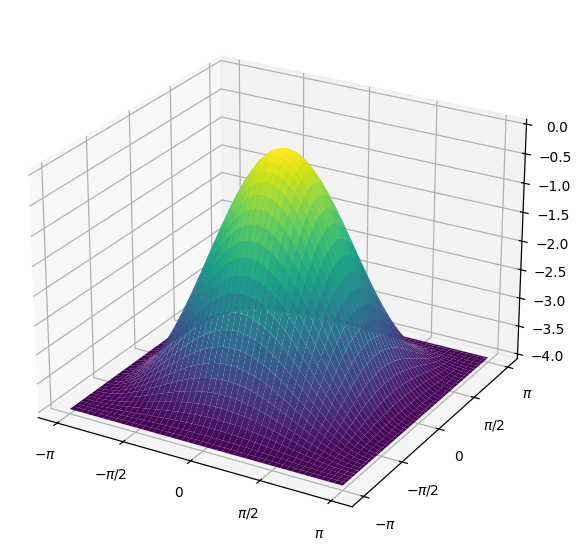

In [ ]:
K0, K1, Z = laplacian_surface_data("bri", d=D, grid_size=GRID_SIZE)
surface3d(K0, K1, Z,
        #   title=r"2D Brillouin Laplacian  $a^2\,\hat{\Delta}_{\rm bri}(k)$",
        #   zlabel=r"$a^2\,\hat{\Delta}_{\rm bri}$"
          )
plt.show()

## Figure 2 — Derivatives

We plot the imaginary part $\mathrm{Im}\,\hat\nabla_0(k)$ (the derivative direction is
$\mu=0$, i.e. $k_0\equiv k_1$ on the horizontal axis).

### Plot 3: Standard derivative $\mathrm{Im}\,\hat\nabla^{\rm std}_0(k)$

A pure $\sin(k_1)$, with **no structure in the transverse direction** $k_2$.

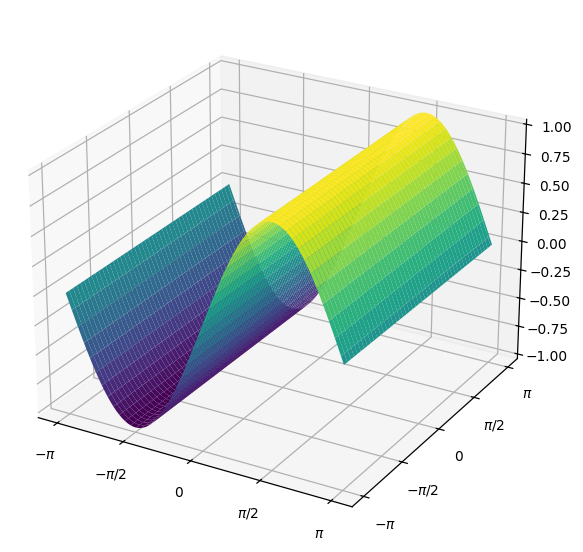

In [ ]:
K0, K1, Z = derivative_surface_data("std", mu=0, d=D, grid_size=GRID_SIZE)
surface3d(K0, K1, Z,
        #   title=r"2D Standard derivative  $\mathrm{Im}\,\hat{\nabla}^{\rm std}_{0}(k)$",
        #   zlabel=r"$\mathrm{Im}\,\hat{\nabla}^{\rm std}_{0}$"
        )
plt.show()

### Plot 4: Isotropic derivative $\mathrm{Im}\,\hat\nabla^{\rm iso}_0(k)$

Modulates the transverse direction $k_2$ — but less pronouncedly than the Brillouin
derivative (which goes to a strict zero on the whole boundary).

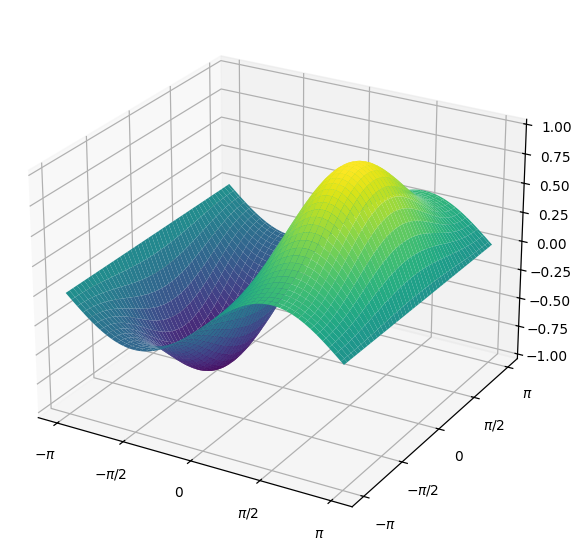

In [ ]:
K0, K1, Z = derivative_surface_data("iso", mu=0, d=D, grid_size=GRID_SIZE)
surface3d(K0, K1, Z,
        #   title=r"2D Isotropic derivative  $\mathrm{Im}\,\hat{\nabla}^{\rm iso}_{0}(k)$",
        #   zlabel=r"$\mathrm{Im}\,\hat{\nabla}^{\rm iso}_{0}$"
        )
plt.show()